# Data Preprocessing – Chronic Kidney Disease Dataset

### 1. Introduction

In this assignment, we work with the Chronic Kidney Disease (CKD) dataset from the UCI Machine Learning Repository.

### 2. Setup and Data Loading

We use the ucimlrepo package to load the dataset directly.

In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

#### Load the CKD dataset       

In [60]:
# fetch dataset
chronic_kidney_disease = fetch_ucirepo(id=336)

# data (as pandas dataframes)
X = chronic_kidney_disease.data.features
y = chronic_kidney_disease.data.targets


#### Dataset description and variables

In [61]:
# metadata
print(chronic_kidney_disease.metadata)

# variable information
print(chronic_kidney_disease.variables)

{'uci_id': 336, 'name': 'Chronic Kidney Disease', 'repository_url': 'https://archive.ics.uci.edu/dataset/336/chronic+kidney+disease', 'data_url': 'https://archive.ics.uci.edu/static/public/336/data.csv', 'abstract': 'This dataset can be used to predict the chronic kidney disease and it can be collected from the hospital nearly 2 months of period.', 'area': 'Other', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 400, 'num_features': 24, 'feature_types': ['Real'], 'demographics': ['Age'], 'target_col': ['class'], 'index_col': None, 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 2015, 'last_updated': 'Mon Mar 04 2024', 'dataset_doi': '10.24432/C5G020', 'creators': ['L. Rubini', 'P. Soundarapandian', 'P. Eswaran'], 'intro_paper': None, 'additional_info': {'summary': 'We use the following representation to collect the dataset\r\n                        age\t\t-\tage\t\r\n\t\t\tbp\t\t-\tblood pressure\r\n\t\t\tsg\t

### 3. Create a Single DataFrame

We combine the feature data (X) and the target variable (y) into one DataFrame.

In [62]:
df = pd.concat([X, y], axis=1)
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


## 4. Select Required Columns
We keep only the required columns:

In [63]:
columns_needed = [
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "bgr",
    "bu",
    "sod",
    "pot",
    "hemo",
    "pcv",
    "wbcc",
    "rbcc",
    "class"
]

df = df[columns_needed]

## 5. Data Cleaning and Transformation Pipeline
#### 5.1 Convert hemoglobin from g/dl to g/l

Original unit: g/dl
Required unit: g/l



In [64]:
df["hemo"] = df["hemo"] * 10

#### 5.2 Recode the class column

ckd → a (affected)

notckd → c (control)

In [65]:
df["class"] = df["class"].map({"ckd": "a", "notckd": "c"})

#### 5.3 Remove rows with 3 or more missing values

In [66]:
df_clean = df[df.isnull().sum(axis=1) < 3]

#### Number of rows left

In [67]:
rows_left = df_clean.shape[0]
rows_left

265

### 6. Split the Dataset

We split the data into two DataFrames:

Affected individuals (a)

Control individuals (c)

In [68]:
df_affected = df_clean[df_clean["class"] == "a"]
df_control = df_clean[df_clean["class"] == "c"]

Display and row counts

In [69]:
df_affected.head(), df_control.head()
len(df_affected), len(df_control)

(126, 139)

## 7. Basic Statistics

We calculate summary statistics for each group.

In [70]:
df_affected.describe()
df_control.describe()

,age,bp,sg,al,su,bgr,bu,sod,pot,hemo,pcv,wbcc,rbcc
count,139.000000,137.000000,139.000000,139.0,139.0,135.000000,135.000000,136.000000,136.000000,137.000000,138.000000,136.000000,136.000000
mean,46.568345,71.313869,1.022482,0.0,0.0,107.385185,32.874074,141.735294,4.335294,151.883212,46.246377,7708.088235,5.380882
std,15.903719,8.559267,0.002509,0.0,0.0,18.747730,11.482257,4.792332,0.596351,12.845270,4.107695,1815.164727,0.592986
min,12.000000,60.000000,1.020000,0.0,0.0,70.000000,10.000000,135.000000,3.300000,130.000000,40.000000,4300.000000,4.500000
25%,34.000000,60.000000,1.020000,0.0,0.0,93.000000,23.500000,138.000000,3.700000,141.000000,43.000000,6300.000000,4.900000
50%,46.000000,70.000000,1.020000,0.0,0.0,107.000000,33.000000,141.000000,4.500000,150.000000,46.000000,7450.000000,5.300000
75%,58.000000,80.000000,1.025000,0.0,0.0,123.500000,44.000000,146.000000,4.900000,162.000000,50.000000,9225.000000,5.900000
max,80.000000,80.000000,1.025000,0.0,0.0,140.000000,50.000000,150.000000,5.000000,178.000000,54.000000,11000.000000,6.500000


## 8. Histograms for Numerical Columns
#### Affected individuals

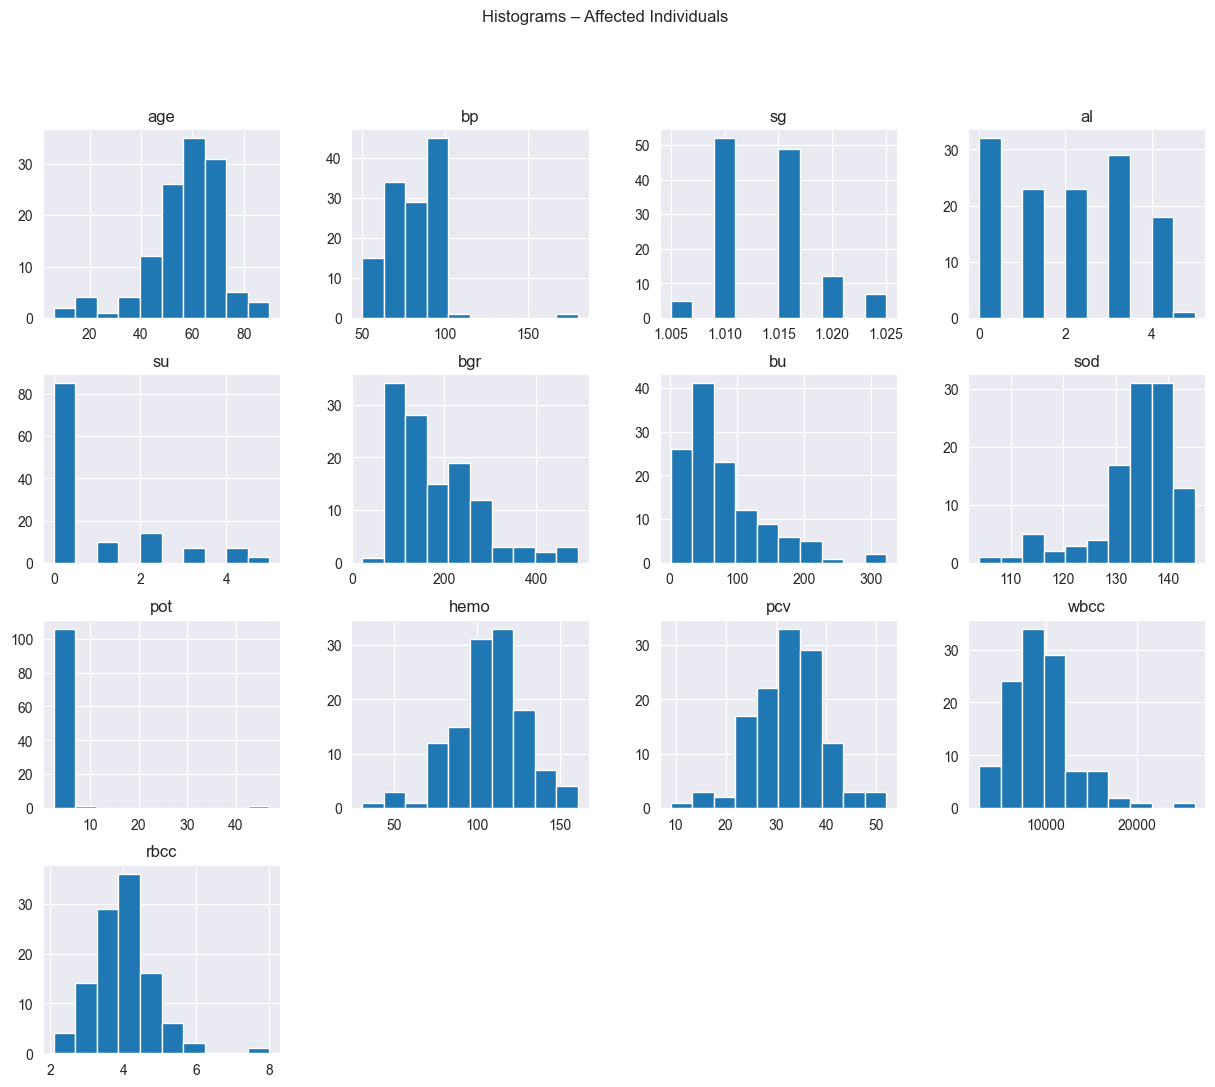

In [71]:
df_affected.hist(figsize=(15, 12))
plt.suptitle("Histograms – Affected Individuals")
plt.show()

#### Control individuals

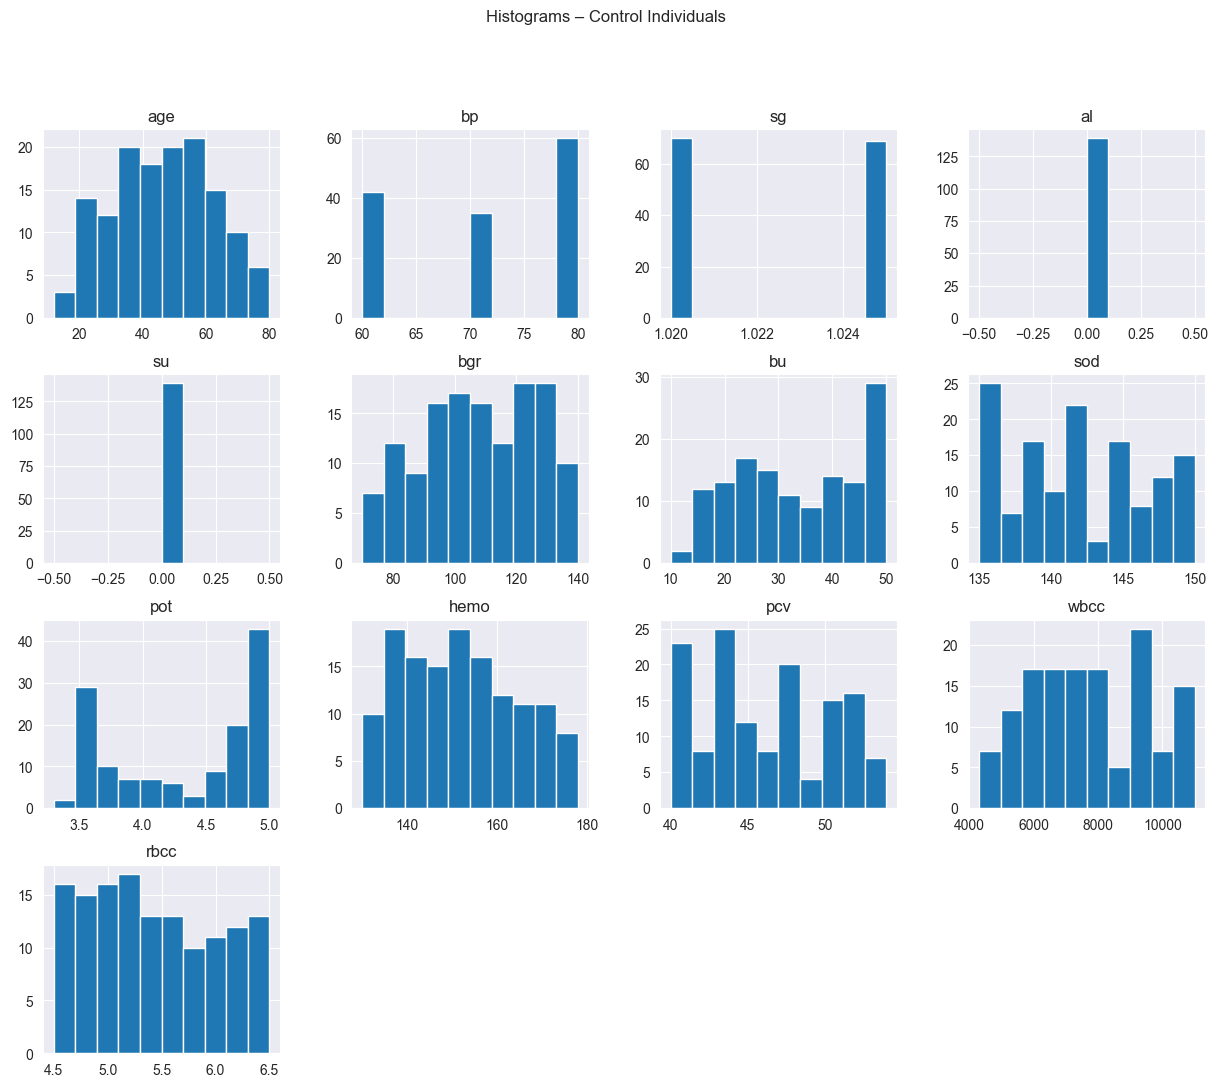

In [72]:
df_control.hist(figsize=(15, 12))
plt.suptitle("Histograms – Control Individuals")
plt.show()

#### Outliers

Some columns (for example blood urea, white blood cell count, and blood glucose) show extreme values.

##### Possible ways to handle outliers:

    - Remove extreme values using IQR or z-score

    - Cap values at reasonable medical limits

    - Keep them if they are medically meaningful

## 9. Correlation Matrix
#### Affected individuals

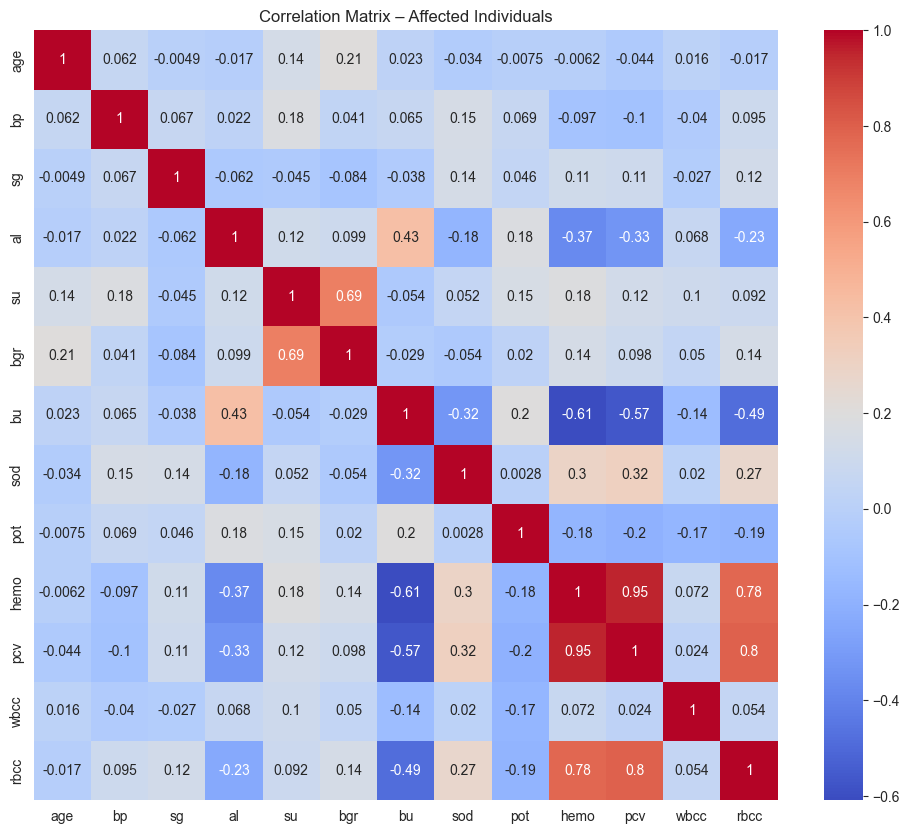

In [73]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_affected.drop(columns=["class"]).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix – Affected Individuals")
plt.show()

#### Control individuals

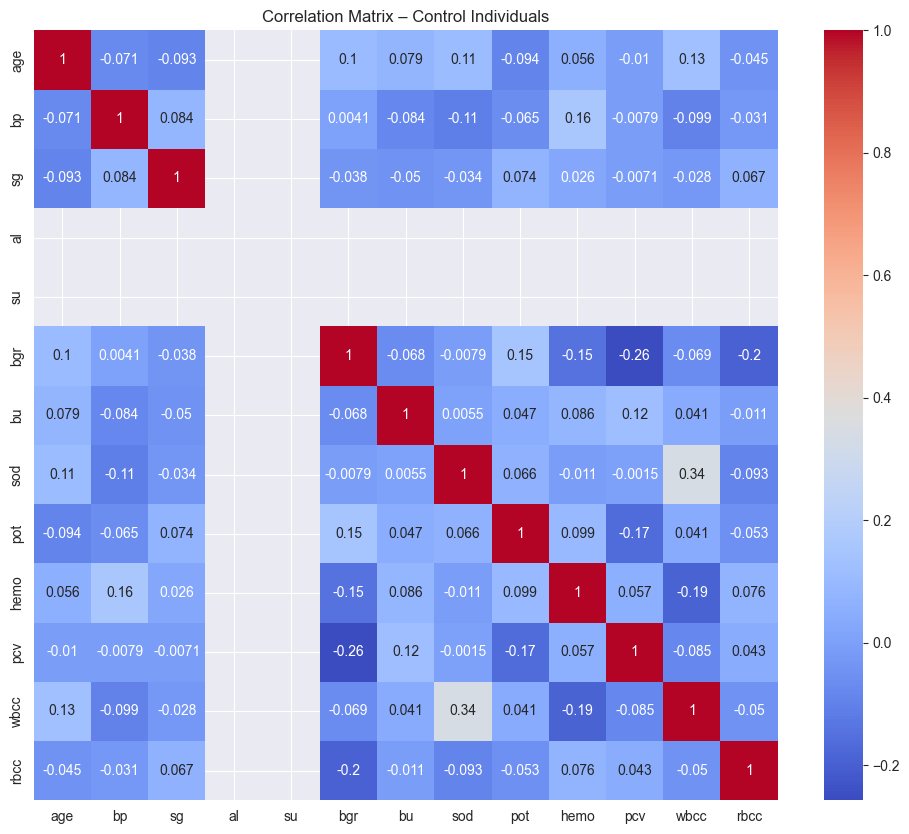

In [74]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_control.drop(columns=["class"]).corr(),
    annot=True,
    cmap="coolwarm"
)
plt.title("Correlation Matrix – Control Individuals")
plt.show()

## 10. Interpretation

In affected patients, strong correlations appear between blood urea, creatinine-related indicators, and hemoglobin

Control patients show weaker correlations overall

This suggests kidney disease strongly affects blood chemistry relationships